# Visualizing Two Variables

**Module 2: Data Visualization** | Lean Six Sigma Data Analytics

---

## The Decision Tree

Choosing the right graph depends on the type of your Y and X variables:

| Y Variable | X Variable | Graph Type |
|------------|------------|------------|
| Numerical | Numerical | **Scatterplot** |
| Numerical | Categorical | **Boxplot with groups** |
| Categorical | Numerical | **Transposed Boxplot** |
| Categorical | Categorical | **Stacked Bar Chart** |

In [2]:
# Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

DATA_FILE = '../data/da-lss.xlsx'
xlsx = pd.ExcelFile(DATA_FILE)
print('Data loaded successfully!')

Data loaded successfully!


---

## 1. Scatterplot (Numerical Y + Numerical X)

**Context:** Coffee production—is caffeine content related to extraction time?

- Y: Caffeine content (numerical)
- X: Extraction time (numerical)

In [3]:
# Load Caffeine-2 data
caffeine2 = pd.read_excel(xlsx, sheet_name='Caffeine-2', skiprows=6)
caffeine2.columns = ['Measurement', 'Caffeine_Pct', 'Extraction_Time']
caffeine2 = caffeine2.dropna()
caffeine2['Caffeine_Pct'] = pd.to_numeric(caffeine2['Caffeine_Pct'], errors='coerce')
caffeine2['Extraction_Time'] = pd.to_numeric(caffeine2['Extraction_Time'], errors='coerce')
caffeine2 = caffeine2.dropna()

print(f'Dataset: {caffeine2.shape[0]} measurements')
caffeine2.head()

Dataset: 50 measurements


,Measurement,Caffeine_Pct,Extraction_Time
1,1,0.065758,35.515587
2,2,0.058861,38.446456
3,3,0.033810,42.320815
4,4,0.089381,33.280603
5,5,0.067373,36.690363


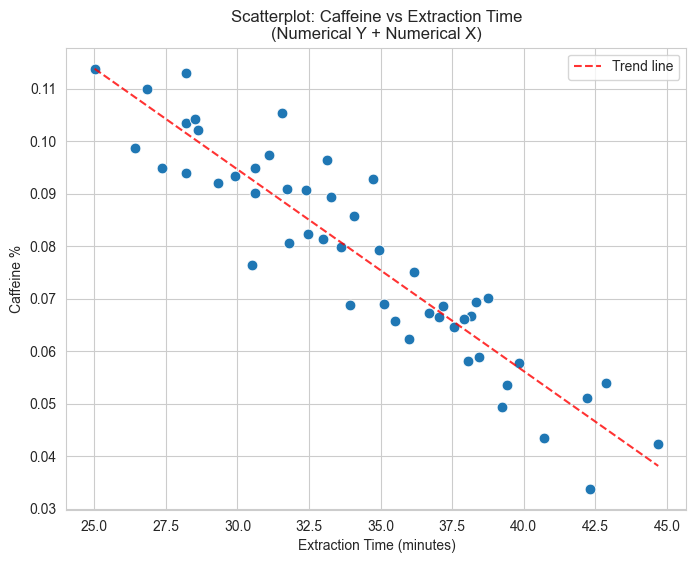

Interpretation:
  - Dots form a downward line → NEGATIVE relationship
  - As extraction time increases, caffeine content decreases


In [4]:
# Scatterplot - equivalent to Minitab: Graph > Scatterplot > Simple
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Extraction_Time', y='Caffeine_Pct', data=caffeine2, s=60)
plt.xlabel('Extraction Time (minutes)')
plt.ylabel('Caffeine %')
plt.title('Scatterplot: Caffeine vs Extraction Time\n(Numerical Y + Numerical X)')

# Add trend line
z = np.polyfit(caffeine2['Extraction_Time'], caffeine2['Caffeine_Pct'], 1)
p = np.poly1d(z)
x_sorted = caffeine2['Extraction_Time'].sort_values()
plt.plot(x_sorted, p(x_sorted), 'r--', alpha=0.8, label='Trend line')
plt.legend()
plt.show()

print('Interpretation:')
print('  - Dots form a downward line → NEGATIVE relationship')
print('  - As extraction time increases, caffeine content decreases')

### Scatterplot Patterns

| Pattern | Interpretation |
|---------|----------------|
| Dots form upward line | Positive relationship |
| Dots form downward line | Negative relationship |
| Dots form curve | Curved/non-linear relationship |
| Dots clustered in groups | Possible subpopulations |
| Dots scattered randomly | No relationship |

---

## 2. Boxplot with Groups (Numerical Y + Categorical X)

**Context:** Coffee production—does caffeine content differ by extractor machine?

- Y: Caffeine content (numerical)
- X: Extractor machine number (categorical)

In [5]:
# Load Caffeine-3 data
caffeine3 = pd.read_excel(xlsx, sheet_name='Caffeine-3', skiprows=6)
caffeine3.columns = ['Caffeine_Pct', 'Extractor', 'Batch']
caffeine3 = caffeine3.dropna()
caffeine3['Caffeine_Pct'] = pd.to_numeric(caffeine3['Caffeine_Pct'], errors='coerce')
caffeine3 = caffeine3.dropna()

print(f'Dataset: {caffeine3.shape[0]} measurements')
print(f'Extractors: {caffeine3["Extractor"].unique()}')
caffeine3.head()

Dataset: 60 measurements
Extractors: [1 2 3]


,Caffeine_Pct,Extractor,Batch
1,0.053180,1,718
2,0.056994,2,718
3,0.112809,3,718
4,0.052463,1,718
5,0.083227,2,718


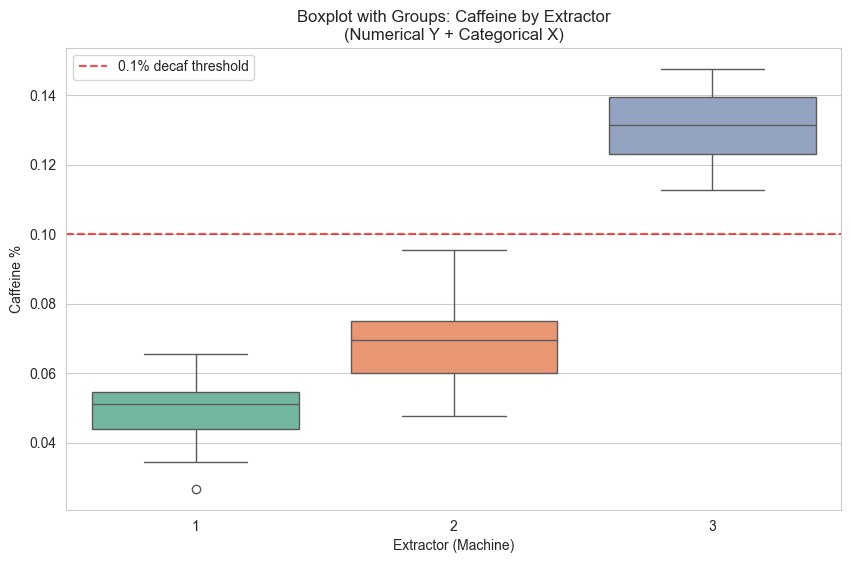

Summary by Extractor:


,N,Mean,Median,Max
Extractor,,,,
1,20,0.0486,0.0511,0.0656
2,20,0.0689,0.0696,0.0955
3,20,0.1310,0.1312,0.1476



Machine(s) exceeding 0.1% threshold: [3]


In [6]:
# Boxplot with groups - equivalent to Minitab: Graph > Boxplot > With Groups
plt.figure(figsize=(10, 6))
sns.boxplot(x='Extractor', y='Caffeine_Pct', data=caffeine3, 
            hue='Extractor', palette='Set2', legend=False)
plt.axhline(0.1, color='red', linestyle='--', alpha=0.7, label='0.1% decaf threshold')
plt.xlabel('Extractor (Machine)')
plt.ylabel('Caffeine %')
plt.title('Boxplot with Groups: Caffeine by Extractor\n(Numerical Y + Categorical X)')
plt.legend()
plt.show()

# Summary
print('Summary by Extractor:')
summary = caffeine3.groupby('Extractor')['Caffeine_Pct'].agg(['count', 'mean', 'median', 'max'])
summary.columns = ['N', 'Mean', 'Median', 'Max']
display(summary.round(4))

# Which machines exceed threshold?
exceeds = caffeine3.groupby('Extractor')['Caffeine_Pct'].apply(lambda x: (x > 0.1).any())
problem_machines = exceeds[exceeds].index.tolist()
if problem_machines:
    print(f'\nMachine(s) exceeding 0.1% threshold: {problem_machines}')

---

## 3. Transposed Boxplot (Categorical Y + Numerical X)

**Context:** University success—does high school math grade predict passing the first year?

- Y: Pass first year (categorical: Yes/No)
- X: High school math grade (numerical)

In [7]:
# Load Student data
student = pd.read_excel(xlsx, sheet_name='Student', skiprows=5)
student.columns = ['Student', 'Math_Grade', 'Pass']
student = student.dropna()
student['Math_Grade'] = pd.to_numeric(student['Math_Grade'], errors='coerce')
student = student.dropna()

print(f'Dataset: {student.shape[0]} students')
print(f'Pass values: {student["Pass"].unique()}')
student.head()

Dataset: 25 students
Pass values: ['No' 'Yes']


,Student,Math_Grade,Pass
1,1,7.0,No
2,2,7.0,Yes
4,4,8.0,No
5,5,8.0,Yes
6,6,9.0,No


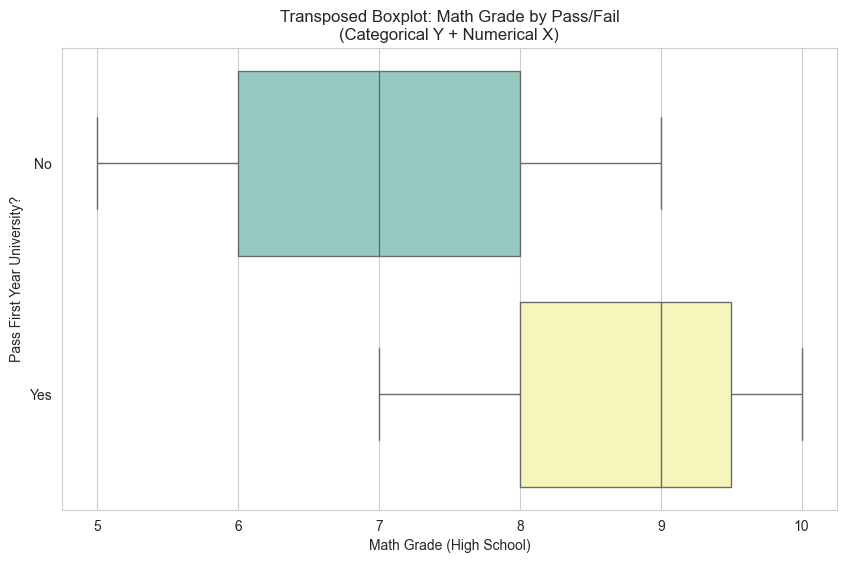

Summary by Pass/Fail:


,N,Mean Grade,Median Grade
Pass,,,
No,14,7.07,7.0
Yes,11,8.82,9.0



Interpretation:
  - Students who passed had higher math grades on average
  - Math grade appears to be a predictor of university success


In [8]:
# Transposed boxplot - equivalent to Minitab: Graph > Boxplot > With Groups (Transpose)
plt.figure(figsize=(10, 6))
sns.boxplot(x='Math_Grade', y='Pass', data=student, 
            hue='Pass', palette='Set3', legend=False, orient='h')
plt.xlabel('Math Grade (High School)')
plt.ylabel('Pass First Year University?')
plt.title('Transposed Boxplot: Math Grade by Pass/Fail\n(Categorical Y + Numerical X)')
plt.show()

# Summary
print('Summary by Pass/Fail:')
summary = student.groupby('Pass')['Math_Grade'].agg(['count', 'mean', 'median'])
summary.columns = ['N', 'Mean Grade', 'Median Grade']
display(summary.round(2))

print('\nInterpretation:')
print('  - Students who passed had higher math grades on average')
print('  - Math grade appears to be a predictor of university success')

---

## 4. Stacked Bar Chart (Categorical Y + Categorical X)

**Context:** Hospital specialists—do specialists treat patients in different departments equally?

- Y: Department (categorical: A1, A4)
- X: Specialist (categorical: P, Q, R)

In [9]:
# Load Hospital data
hospital = pd.read_excel(xlsx, sheet_name='Hospital', skiprows=7)
hospital.columns = ['Patient', 'Specialist', 'Department']
hospital = hospital.dropna()

print(f'Dataset: {hospital.shape[0]} patients')
print(f'Specialists: {hospital["Specialist"].unique()}')
print(f'Departments: {hospital["Department"].unique()}')
hospital.head()

Dataset: 269 patients
Specialists: ['P' 'Q' 'R']
Departments: ['A1' 'A4']


,Patient,Specialist,Department
0,1,P,A1
1,2,P,A1
2,3,Q,A1
3,4,R,A1
4,5,Q,A1


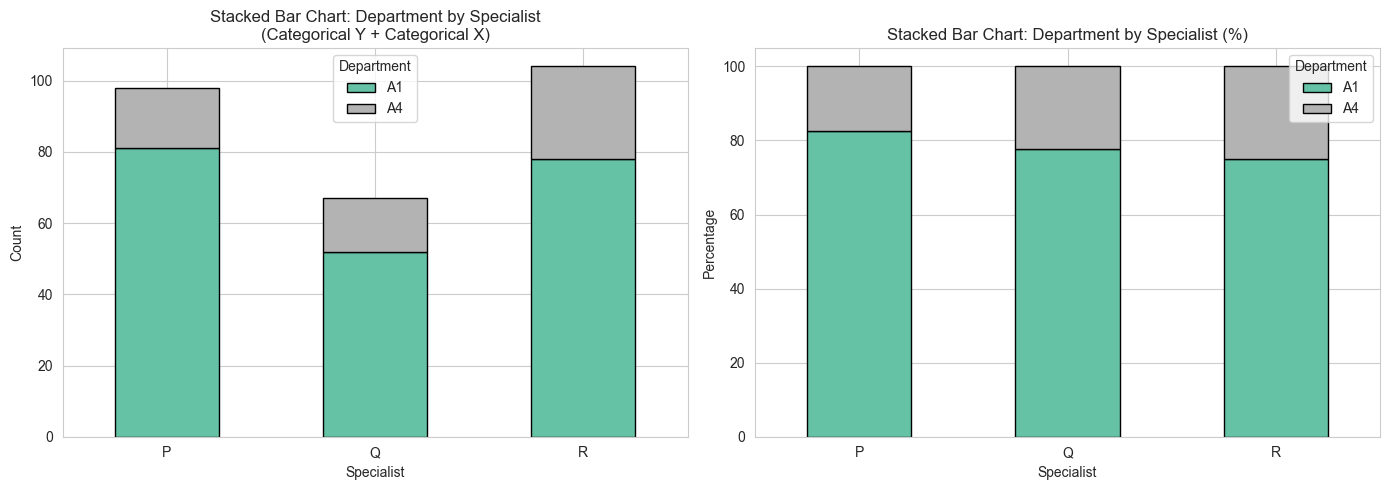

Cross Tabulation:


Department,A1,A4,All
Specialist,,,
P,81,17,98
Q,52,15,67
R,78,26,104
All,211,58,269



Interpretation:
  - Specialist P treats mostly A1 patients
  - Compare proportions to see if specialists distribute evenly across departments


In [10]:
# Stacked bar chart - equivalent to Minitab: Graph > Bar Chart > Stacked
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

crosstab = pd.crosstab(hospital['Specialist'], hospital['Department'])

# Counts
crosstab.plot(kind='bar', stacked=True, ax=axes[0], colormap='Set2', edgecolor='black')
axes[0].set_xlabel('Specialist')
axes[0].set_ylabel('Count')
axes[0].set_title('Stacked Bar Chart: Department by Specialist\n(Categorical Y + Categorical X)')
axes[0].legend(title='Department')
axes[0].tick_params(axis='x', rotation=0)

# Percentages
crosstab_pct = crosstab.div(crosstab.sum(axis=1), axis=0) * 100
crosstab_pct.plot(kind='bar', stacked=True, ax=axes[1], colormap='Set2', edgecolor='black')
axes[1].set_xlabel('Specialist')
axes[1].set_ylabel('Percentage')
axes[1].set_title('Stacked Bar Chart: Department by Specialist (%)')
axes[1].legend(title='Department')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

# Cross tabulation
print('Cross Tabulation:')
display(pd.crosstab(hospital['Specialist'], hospital['Department'], margins=True))

print('\nInterpretation:')
print('  - Specialist P treats mostly A1 patients')
print('  - Compare proportions to see if specialists distribute evenly across departments')

---

## Summary: Choosing the Right Graph

```
┌─────────────────┬─────────────────┬────────────────────────┐
│ Y Variable      │ X Variable      │ Graph Type             │
├─────────────────┼─────────────────┼────────────────────────┤
│ Numerical       │ Numerical       │ Scatterplot            │
│ Numerical       │ Categorical     │ Boxplot with groups    │
│ Categorical     │ Numerical       │ Transposed Boxplot     │
│ Categorical     │ Categorical     │ Stacked Bar Chart      │
└─────────────────┴─────────────────┴────────────────────────┘
```

---

## Key Takeaways

- **First question:** What type are my Y and X variables?
- **Scatterplot:** Both numerical → shows relationship pattern
- **Boxplot with groups:** Numerical Y + Categorical X → compare distributions
- **Transposed Boxplot:** Categorical Y + Numerical X → compare groups on numerical scale
- **Stacked Bar Chart:** Both categorical → show frequency combinations
- Always let the variable types guide your graph choice